# Homework 1

### Deadline: Wednesday 19 March 2024 (by 19h00)

### Credits: 20 points

### Instructions:

- When you finish, please submit a single **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The quiz is individual. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems.

# Name:  Juan Daniel Vasconez

## 1. Thermodynamics of ideal and real gases (10 points)

The equation of state (EOS) for ideal gases is given by:

$$P\,V = n\,R\,T$$

where:
- $P$ is the pressure,
- $V$ is the volume,
- $T$ is the temperature,
- $R = 0.08206\,\rm L\,atm/(mol\,K)$ is the ideal gas constant,
- $n$ is the number of moles.

On the other hand, real gases can be modeled with the van der Waals equation (EOS):

$$\left(P + \frac{n^2 a}{V^2}\right)(V - n\,b) = n\,R\,T$$

where $a$ and $b$ are constants that depend on the gas composition. The table below shows typical values of these constants for 6 gases:

| Gas             | $a\,\rm (L^2\,atm/mol^2)$ | $b\,\rm (L/mol)$ |
|-----------------|---------------------|-----------------|
| Hydrogen ($\rm H_2$)   | 0.248               | 0.0266          |
| Nitrogen ($\rm N_2$)   | 1.370               | 0.0387          |
| Oxygen ($\rm O_2$)     | 1.382               | 0.0319          |
| Chlorine ($\rm Cl_2$)  | 6.579               | 0.0562          |
| Carbon Dioxide ($\rm CO_2$) | 3.592          | 0.0427          |
| Methane ($\rm C\,H_4$)   | 2.253             | 0.0428          |


##### Reference: https://en.wikipedia.org/wiki/Van_der_Waals_constants_(data_page)

### Coding tasks:


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.constants as ctn
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import scipy.optimize as opt

#### Python basics:

**(a)** Create a python function that reads $n$, $T$, $V$, $a$, $b$ and returns a two-element tuple with the thermal pressures $P$, calculated with the ideal gas equation and the van der Waals equation.

**(b)** Define a python dictionary containing the identifiers of all 6 gases as "keys" with their respective $a$ and $b$ constants as elements.

In [ ]:
def pressures(n, T, V, a, b):
    """
    Calculate the pressures using the ideal gas equation and the van der Waals equation.

    Parameters:
    n (float): Number of moles
    T (float): Temperature in Kelvin
    V (float): Volume in liters
    a (float): van der Waals constant a (L^2 atm / mol^2)
    b (float): van der Waals constant b (L / mol)

    Returns:
    tuple: A two-element tuple containing:
        - p1 (float): Pressure calculated using the van der Waals equation
        - p2 (float): Pressure calculated using the ideal gas equation
    """
    R = 0.08206  # Ideal gas constant in L atm/(mol K)

    # Calculate pressure using the van der Waals equation
    p1 = ((n * R * T) / (V - n * b)) - (n**2 * a) / V**2

    # Calculate pressure using the ideal gas equation
    p2 = (n * R * T) / V

    return p1, p2

# Dictionary containing the van der Waals constants for different gases
gases = {
    "H2": {"a": 0.248, "b": 0.0266},
    "N2": {"a": 1.370, "b": 0.0387},
    "O2": {"a": 1.382, "b": 0.0319},
    "Cl2": {"a": 6.579, "b": 0.0562},
    "CO2": {"a": 3.592, "b": 0.0427},
    "CH4": {"a": 2.253, "b": 0.0428}
}


#### Pressure-Volume (PV) plots:

**(c)** Generate a 1D volume vector covering the range from $0.5$ to $5\,\rm L$, and fix the number of moles at $n=1\,\rm mol$ and the temperature of the gas at $T=298\,\rm K$.

**(d)** Using the values of $a$ and $b$ from the dictionary in point (b), and the inputs in defined (c), call the function created in point (a) to obtain a set of pressure arrays, $P$, with both equations of state for each gas. (**Hint:** a for loop can help access the dictionary elements).

**(e)** Use matplotlib to make a high-quality, labeled, multi-panel figure of the thermal pressure (calculated with both EOS) of all 6 gases as a function of volume. The plot should have $P$ on the Y axis and $V$ on the X axis.

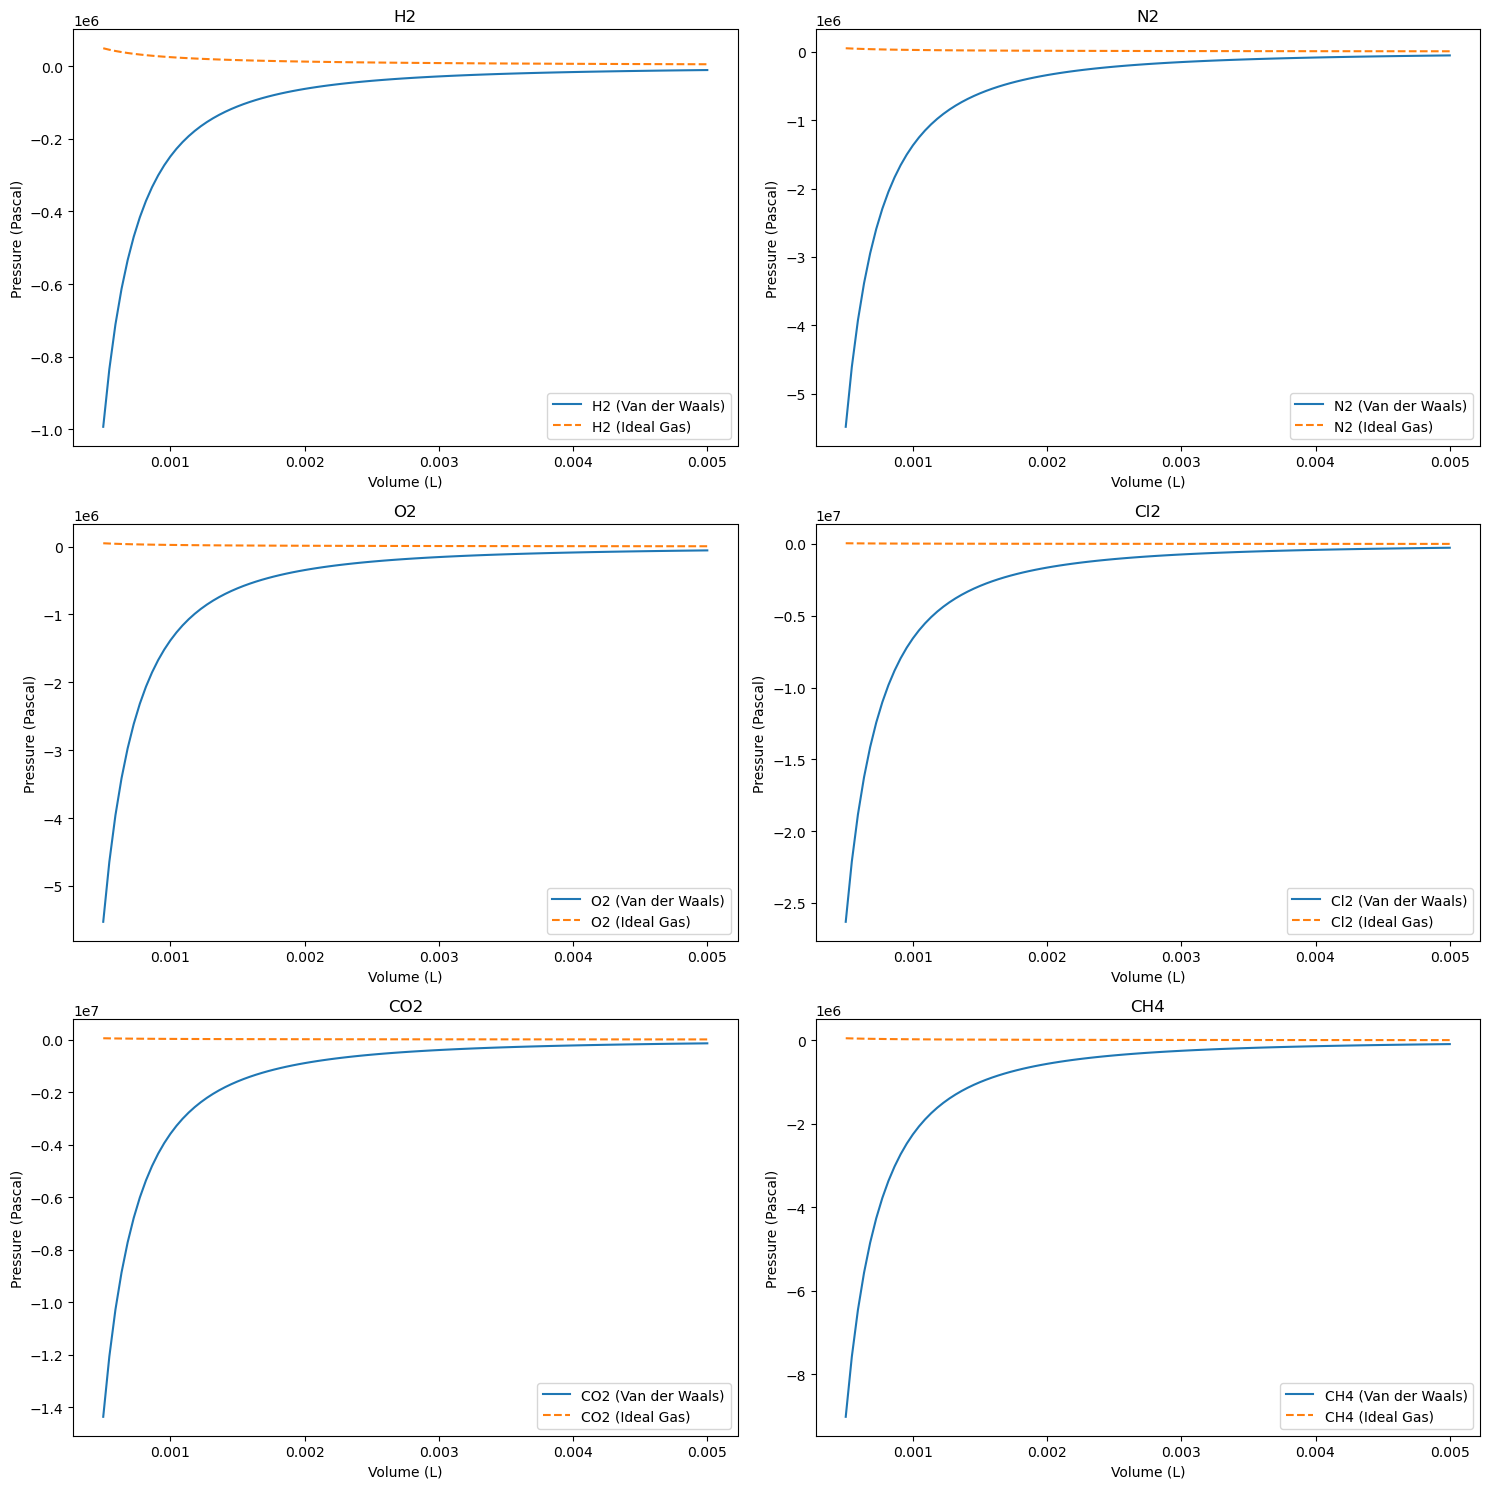

In [5]:
# Generate a 1D volume vector covering the range from 0.5 to 5 L
volume_vector = np.linspace(0.5, 5, 100) * (1e-3)  # Convert to m^3

# Define the number of moles and temperature
n = 1  # Number of moles
T = 298 # Temperature in Kelvin

# Calculate the pressures using both the ideal gas equation and the van der Waals equation for each gas
pressures_results = {
    gas: pressures(n, T, volume_vector, data['a'], data['b']) 
    for gas, data in gases.items()
}

# Create a figure with subplots 
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot the van der Waals and ideal gas equations of state for each gas
for i, (gas, (p1, p2)) in enumerate(pressures_results.items()):
    ax = axes[i]
    ax.plot(volume_vector, p1, label=f'{gas} (Van der Waals)')
    ax.plot(volume_vector, p2, label=f'{gas} (Ideal Gas)', linestyle='--')
    ax.set_xlabel("Volume (L)")
    ax.set_ylabel("Pressure (Pascal)")
    ax.legend()
    ax.set_title(gas)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


#### Temperature surfaces on the PV plane:

**(f)** Now, we want to represent the gas temperature surfaces on the PV plane. Create a new python function that reads $n$, $P$, $V$, $a$, $b$ and returns a two-element tuple with the temperatures $T$, calculated with the ideal gas equation and the van der Waals equation. 

**(g)** Create a 2D pressure-volume (PV) meshgrid using appropriate vectors for thermal pressures and volumes.

**(h)** Use matplotlib to make two high-quality, labeled, multi-panel figures of the 2D temperatures (calculated with both EOS) of all 6 gases as a function of volume. The first figure should show 3D visualisations of the temperature surface. The second figure should show 2D projections of the temperature surface onto the PV plane. All the plots should have $P$ on the Y axis, $V$ on the X axis, and $T$ on the Z axis. 

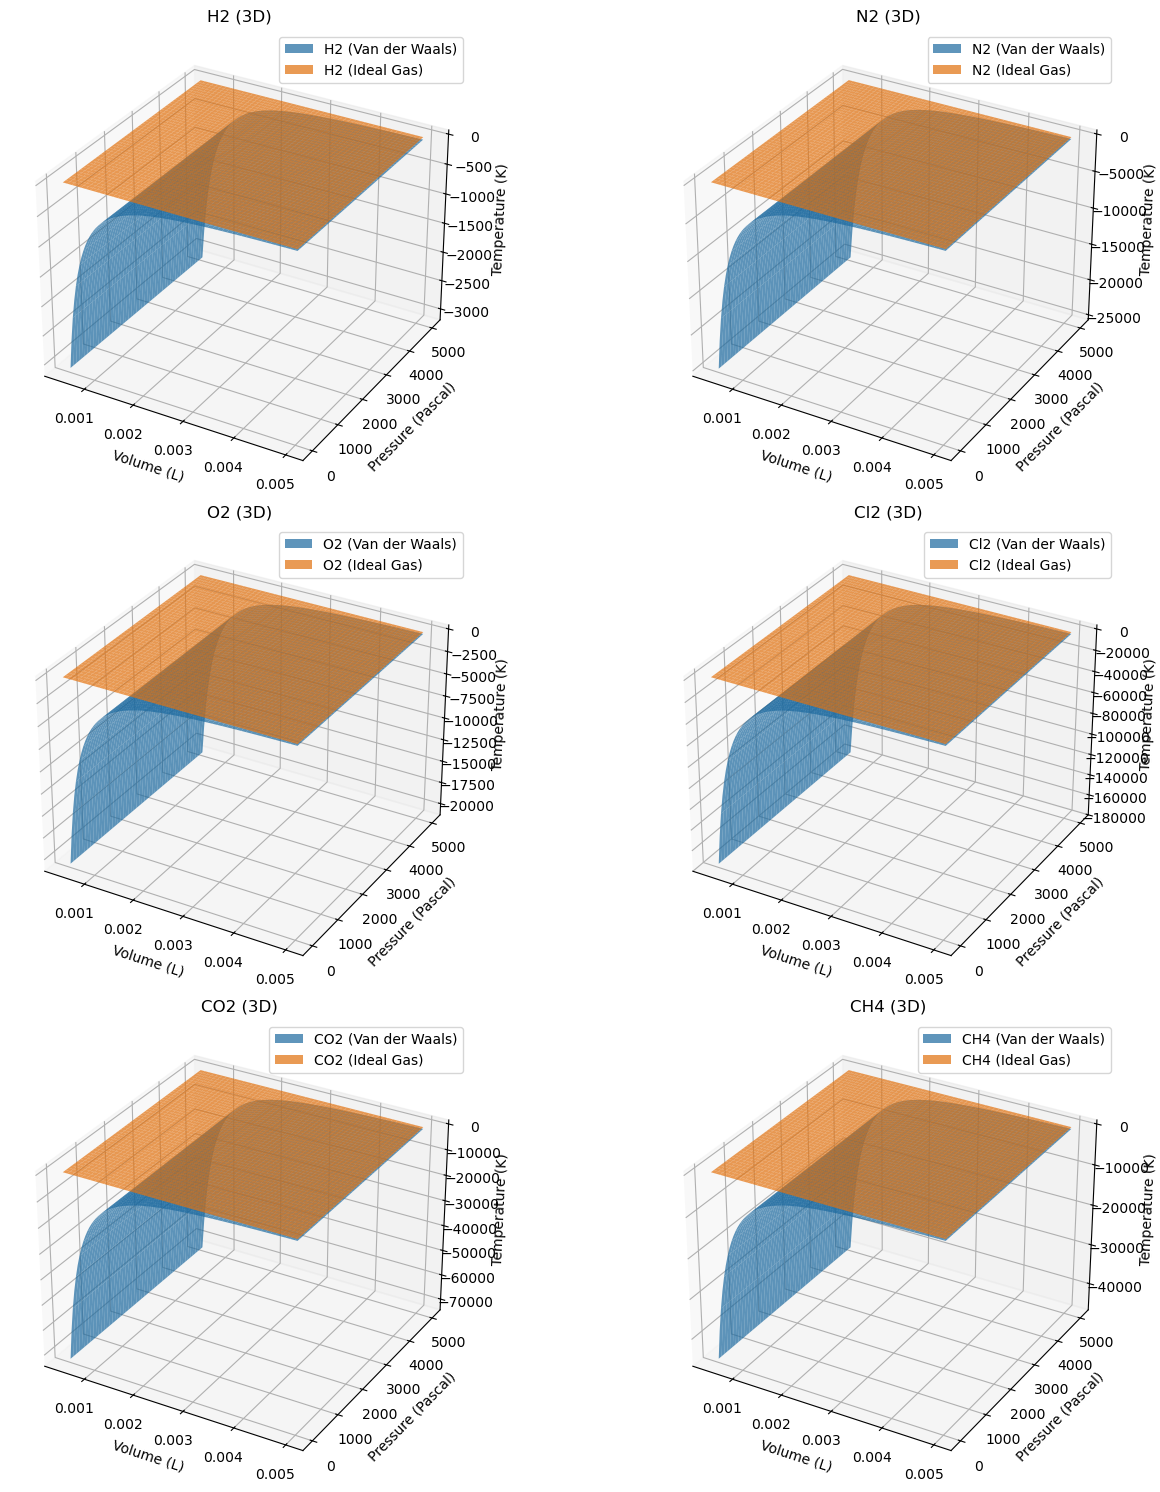

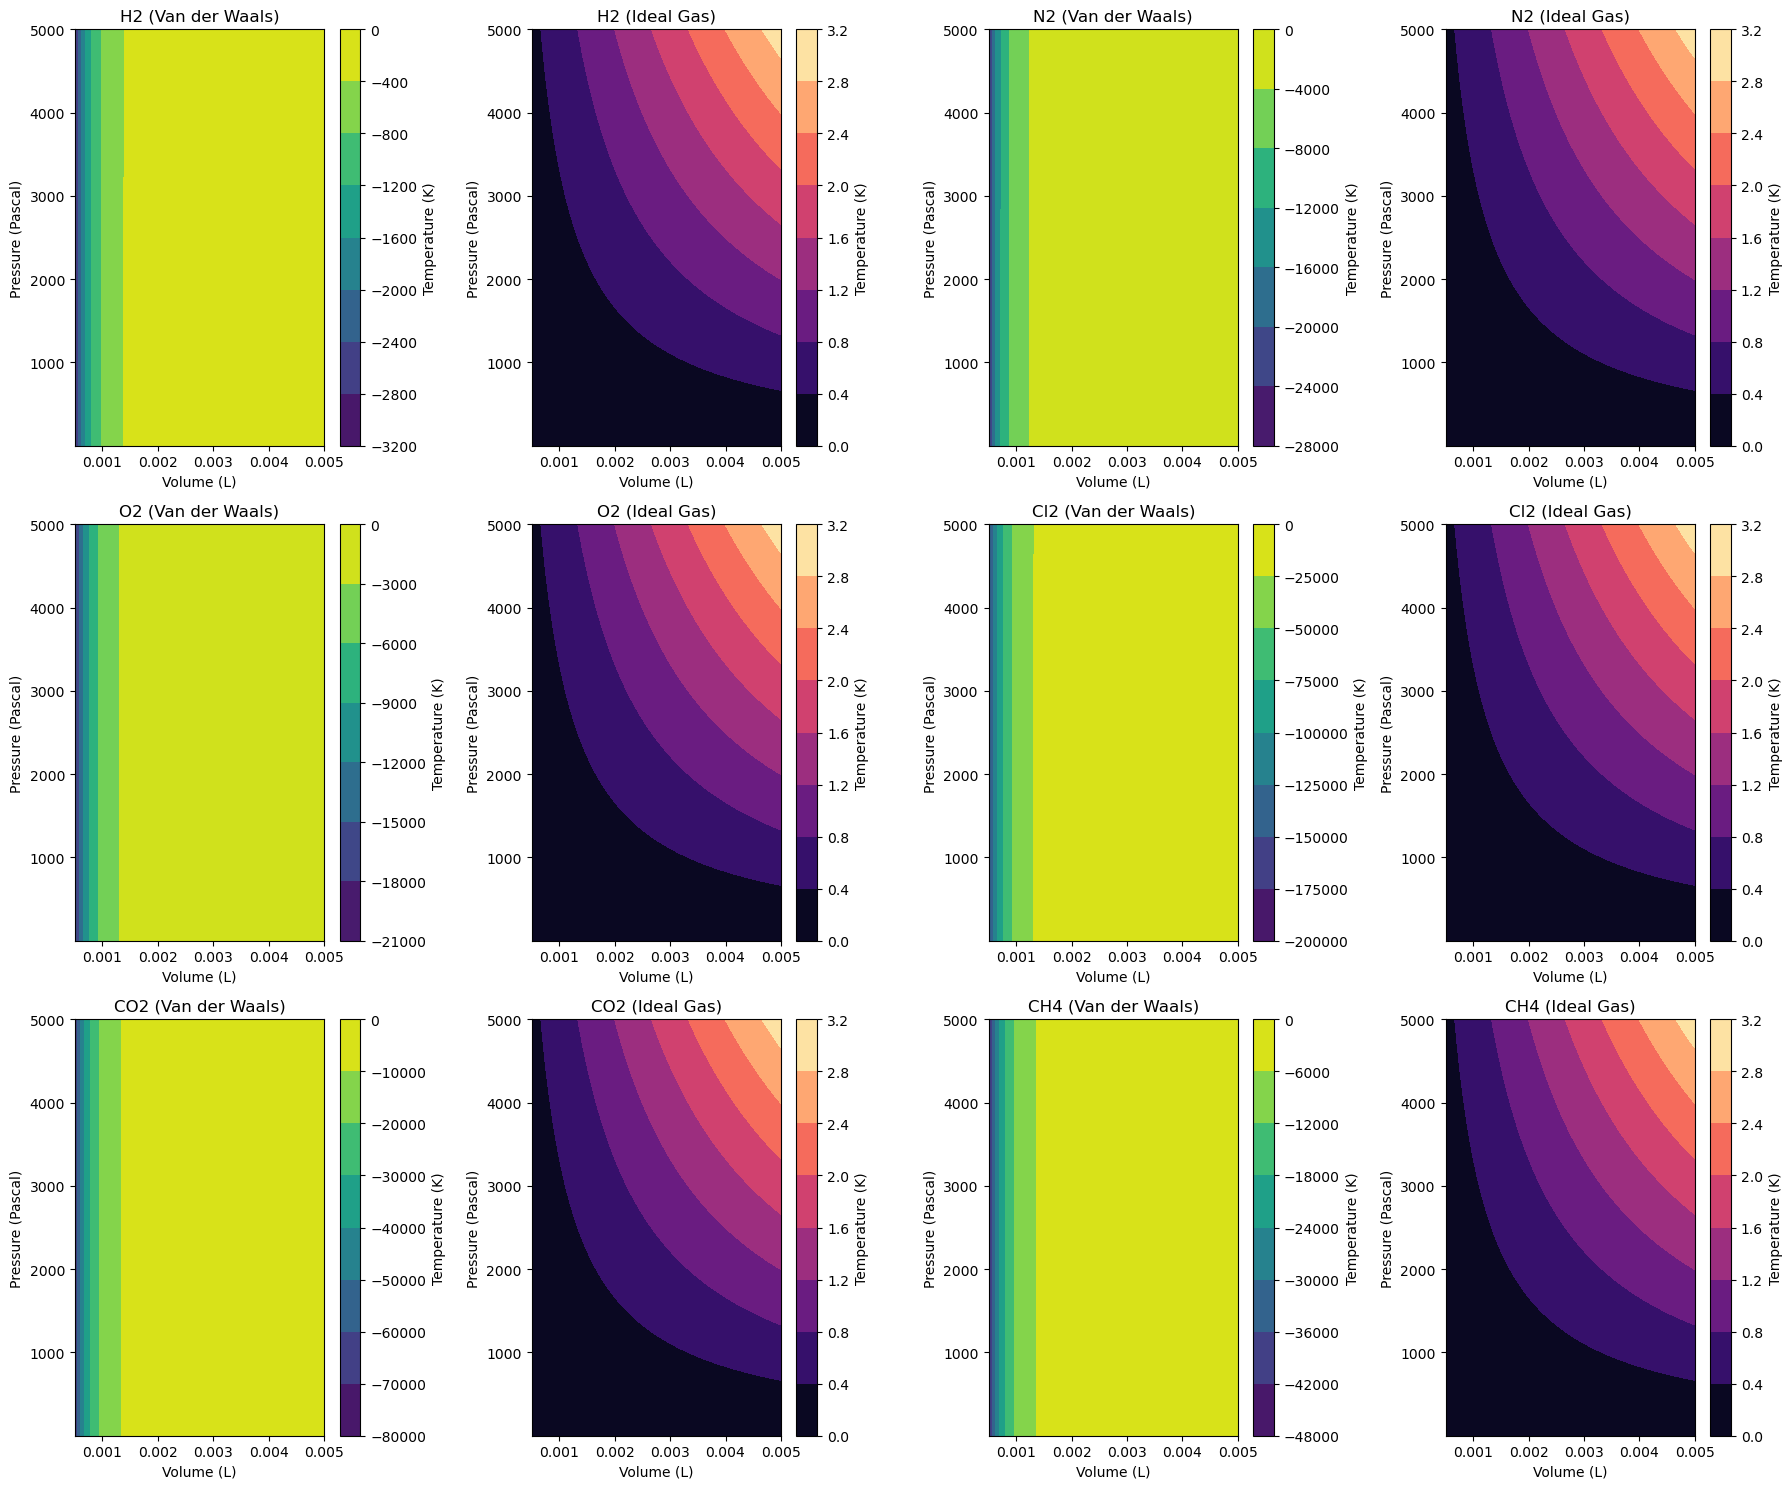

In [6]:
def temps(n,P, V, a, b):
    """
    Calculate the temperatures using the ideal gas equation and the van der Waals equation.

    Parameters:
    n (float): Number of moles
    P (float): Pressure in atm
    V (float): Volume in liters
    a (float): van der Waals constant a (L^2 atm / mol^2)
    b (float): van der Waals constant b (L / mol)

    Returns:
    tuple: A two-element tuple containing:
        - T1 (float): Temperature calculated using the van der Waals equation
        - T2 (float): Temperature calculated using the ideal gas equation
    """
    R = ctn.R  # Ideal gas constant in J/(mol K)

    # Calculate temperature using the van der Waals equation
    T1 = ((P + (n**2 * a) / V**2) * (V - n * b)) / (n * R)

    # Calculate temperature using the ideal gas equation
    T2 = P * V / (n * R)

    return T1, T2

meshgrid = np.meshgrid(volume_vector, np.linspace(0.5, 5000, 1000)) 
volume_matrix, pressure_matrix = meshgrid

temps_results = {
    gas: temps(n, pressure_matrix, volume_matrix, data['a'], data['b'])
    for gas, data in gases.items()
}

# Create a 3D figure with subplots
fig_3d, axes_3d = plt.subplots(3, 2, figsize=(15, 15), subplot_kw={'projection': '3d'})

# Flatten the axes array for easy iteration
axes_3d = axes_3d.flatten()

# Plot the 3D temperature surfaces for each gas
for i, (gas, (T1, T2)) in enumerate(temps_results.items()):
    ax_3d = axes_3d[i]
    ax_3d.plot_surface(volume_matrix, pressure_matrix, T1, label=f'{gas} (Van der Waals)', alpha=0.7)
    ax_3d.plot_surface(volume_matrix, pressure_matrix, T2, label=f'{gas} (Ideal Gas)', alpha=0.7)
    ax_3d.set_xlabel("Volume (L)")
    ax_3d.set_ylabel("Pressure (Pascal)")
    ax_3d.set_zlabel("Temperature (K)")
    ax_3d.set_title(f'{gas} (3D)')
    ax_3d.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Create a 2D figure with subplots
fig_2d, axes_2d = plt.subplots(3, 4, figsize=(18, 15))

# Flatten the axes array for easy iteration
axes_2d = axes_2d.flatten()

# Plot the 2D temperature projections for each gas
for i, (gas, (T1, T2)) in enumerate(temps_results.items()):
    ax_2d = axes_2d[2 * i]
    c1 = ax_2d.contourf(volume_matrix, pressure_matrix, T1, alpha=1)
    ax_2d.set_xlabel("Volume (L)")
    ax_2d.set_ylabel("Pressure (Pascal)")
    ax_2d.set_title(f'{gas} (Van der Waals)')
    fig_2d.colorbar(c1, ax=ax_2d, label='Temperature (K)')
    
    ax_2d = axes_2d[2 * i + 1]
    c2 = ax_2d.contourf(volume_matrix, pressure_matrix, T2, alpha=1, cmap='magma')
    ax_2d.set_xlabel("Volume (L)")
    ax_2d.set_ylabel("Pressure (Pascal)")
    ax_2d.set_title(f'{gas} (Ideal Gas)')
    fig_2d.colorbar(c2, ax=ax_2d, label='Temperature (K)')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()




### Analysis questions:

**(i)** Briefly explain, what do the the $a$ and $b$ constants in the real gas EOS represent physically?

**(j)** Based on the figures you made, what differences do you see between ideal and real gases? When do they coincide or differ?

i) For the real gas EOS the a and b cosntans are free variables finded experimentally and where they represent:
- a: constant related to the strength of intermolecular attractions.
- b: constant related to the volume occupied by the gas molecules themselves. 

j) Both laws look a like for high temperature and low pressures where intermolecular interactions are minimal. In this regime, the real gas behaves similarly to an ideal gas. But start to differ at low temperatures and high presures where real gases deviate more significantly from ideal gas behavior due to intermolecular forces and the finite volume of molecules. 


## 2. Period of the tide using sea level data (10 points)

The goal of this exercise is to calculate the period of the sea level change with the tide in Ecuador. For this, we are going to use sea level measurements from the data base of the University of Hawaii: 

http://uhslc.soest.hawaii.edu/data/?fd

These data sets were collected from more than $500$ tide gauge stations across the globe.

##### Reference: Caldwell, P. C., M. A. Merrifield, P. R. Thompson (2015), Sea level measured by tide gauges from global oceans — the Joint Archive for Sea Level holdings (NCEI Accession 0019568), Version 5.5, NOAA National Centers for Environmental Information, Dataset, doi:10.7289/V5V40S7W.

### Coding tasks:


#### Python I/O:

**(a)** Go to the website of the sea level database and search for measurments from Ecuador. Download the "Research Quality" "hourly" data for all three stations in Ecuador (Santa Cruz, Baltra, and La Libertad). Inspect the data file structure. These data sets are **csv** files with 5 columns each (year, month, day, hour, sea level). The units of the sea level data are $\rm mm$.

**(b)** Create an I/O function that uses pandas to read in the data from these files and return the columns as numpy arrays. You will use the hour and sea level columns for the analysis below.

**(c)** Plot the sea level measurements against the hours for all stations for a first inspection. You will notice there are outliers. Outliers show up as negative values that occur when instruments fail or measurements are missing.

      0  1   2   3     4
0  1985  3  25  15  1435
1  1985  3  25  16  1183
2  1985  3  25  17  1101
3  1985  3  25  18  1210
4  1985  3  25  19  1471
      0  1  2  3     4
0  1949  9  1  5  2481
1  1949  9  1  6  2268
2  1949  9  1  7  2024
3  1949  9  1  8  1841
4  1949  9  1  9  1719
      0   1   2   3     4
0  1978  10  19  17   488
1  1978  10  19  18   675
2  1978  10  19  19  1043
3  1978  10  19  20  1454
4  1978  10  19  21  1850


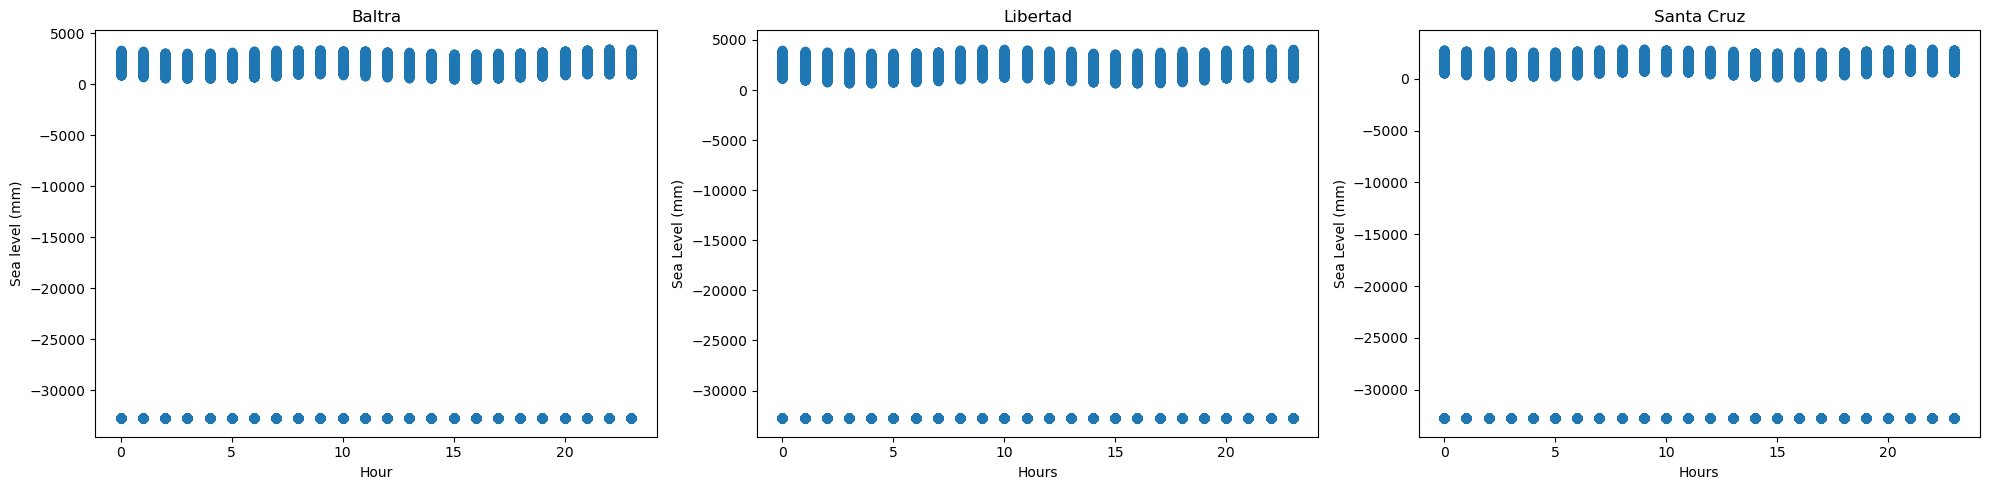

In [7]:
def data_extrac(file):
    """
    Extract the data from a CSV file and return its columns as numpy arrays.

    Parameters:
    file (str): The path to the CSV file.

    Returns:
    List: A list containing the columns of the CSV file as numpy arrays.
    """
    # Read the CSV file using pandas
    data = pd.read_csv(file, header=None)
    print(data.head())

    # Convert each column to a numpy array and store in a list
    file_arrays = [data.iloc[:, i].to_numpy() for i in range(data.shape[1])]
    
    return file_arrays

# Extract data from the CSV files for each station
baltra = data_extrac('baltra.csv')
libertad = data_extrac('la_libertad.csv')
santa_cruz = data_extrac('santa_cruz.csv')

# Create a figure with 3 subplots for each station
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Plot the sea level measurements against the hours for each station
ax[0].scatter(baltra[-2], baltra[-1], label='Baltra')
ax[1].scatter(libertad[-2], libertad[-1], label='Libertad')
ax[2].scatter(santa_cruz[-2], santa_cruz[-1], label='Santa Cruz')

# Set labels and titles for each subplot
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Sea level (mm)')
ax[0].set_title('Baltra')

ax[1].set_xlabel('Hours')
ax[1].set_ylabel('Sea Level (mm)')
ax[1].set_title('Libertad')

ax[2].set_xlabel('Hours')
ax[2].set_ylabel('Sea Level (mm)')
ax[2].set_title('Santa Cruz')

plt.tight_layout()
plt.show()


#### Indexing and clean-up:

**(d)** Create a clean-up function that removes extreme outliers from the data using indexing. Plot again the sea level measurements against the hours for all stations, but using the cleaned-up data wihtout outliers.

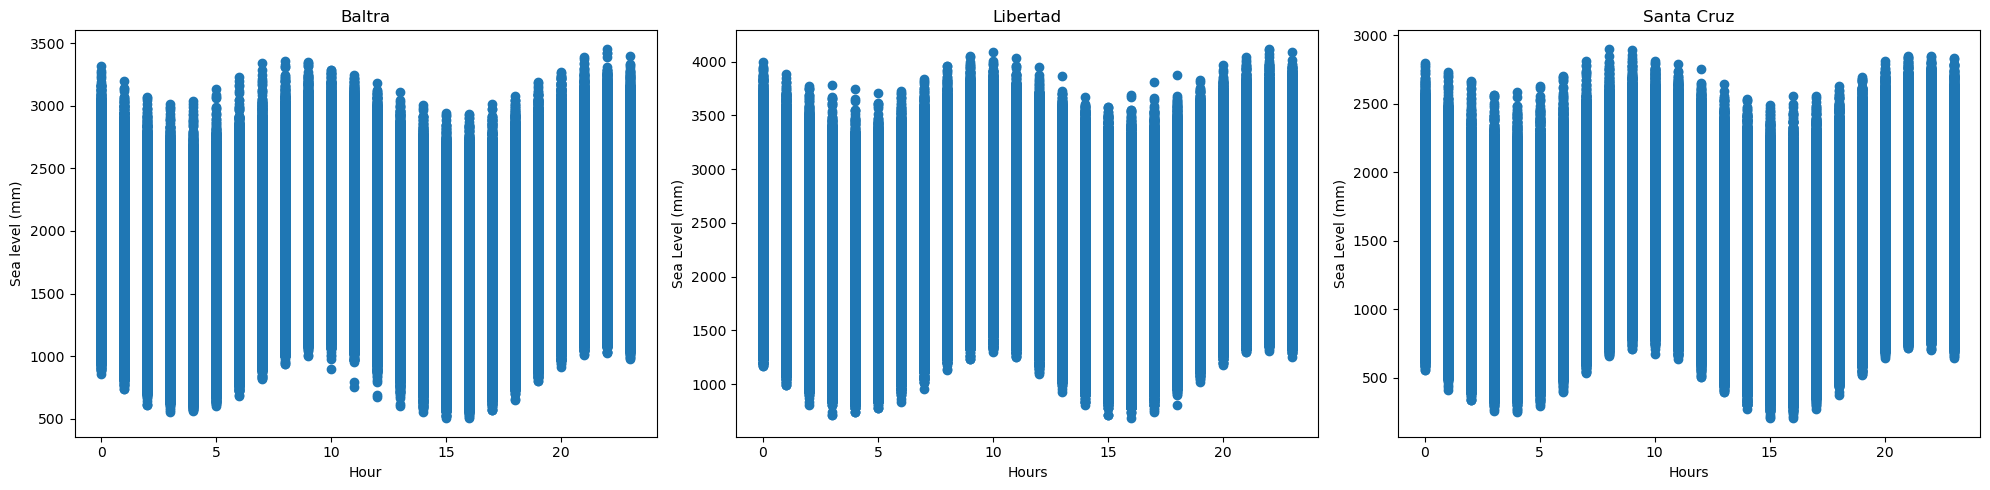

In [8]:
def data_cleaning(data):
    """
    Clean the data by removing values in each row where the corresponding value
    in the last row is negative.

    Parameters:
    data (list of np.ndarray): The input list of arrays.

    Returns:
    list of np.ndarray: The cleaned data with values removed accordingly.
    """
    # Boolean mask for negative values in the last array
    bool_mask = data[-1] < 0

    # Remove elements in each array based on the mask
    for i in range(len(data)):
        data[i] = data[i][~bool_mask]  # Keep values where mask is False

    return data


# Clean the sea level data for each station
baltra = data_cleaning(baltra)
libertad = data_cleaning(libertad)
santa_cruz = data_cleaning(santa_cruz)

# Create a figure with 3 subplots for each station
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Plot the cleaned sea level measurements against the hours for each station
ax[0].scatter(baltra[-2], baltra[-1], label='Baltra')
ax[1].scatter(libertad[-2], libertad[-1], label='Libertad')
ax[2].scatter(santa_cruz[-2], santa_cruz[-1], label='Santa Cruz')

# Set labels and titles for each subplot
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Sea level (mm)')
ax[0].set_title('Baltra')

ax[1].set_xlabel('Hours')
ax[1].set_ylabel('Sea Level (mm)')
ax[1].set_title('Libertad')

ax[2].set_xlabel('Hours')
ax[2].set_ylabel('Sea Level (mm)')
ax[2].set_title('Santa Cruz')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


#### Regression and goodness-of-fit tests:

**(e)** Calculate the average sea level at each hour for Santa Cruz and make a plot of average sea level against hours. Based on the observed trend, propose a model to describe the tide.

**(f)** Fit your model to the data to study the hourly change of the sea level also known as the tide (if you use curvefit() for the regression, I suggest providing ansatz values). Report the best-fit function including uncertainties.

**(g)** Carry out a goodness-of-fit test. For this you need a function that computes the global $\chi^2$ statistic, the number of degrees of freedom, and the reduced $\chi^2$ statistic. Use your function to evaluate your regression.

**(h)** Construct the confidence intervals and show them in 2D parameter space/s. For this you should evaluate the $\chi^2$ statistic in the vicinity of the best-fit values for the free parameters in your model. The confidence interval maps should have one free parameter in the X axis, another free parameter in the Y axis, and the projected $\chi^2$ hypersurface in the $Z$ axis. **Hints:** to create a 2D parameter space as a meshgrid, you should first create vectors with numbers around the best-fit values found in your regressions. 1D plots showing $\chi^2$ as a function of each free parameter may help identify optimal numbers.

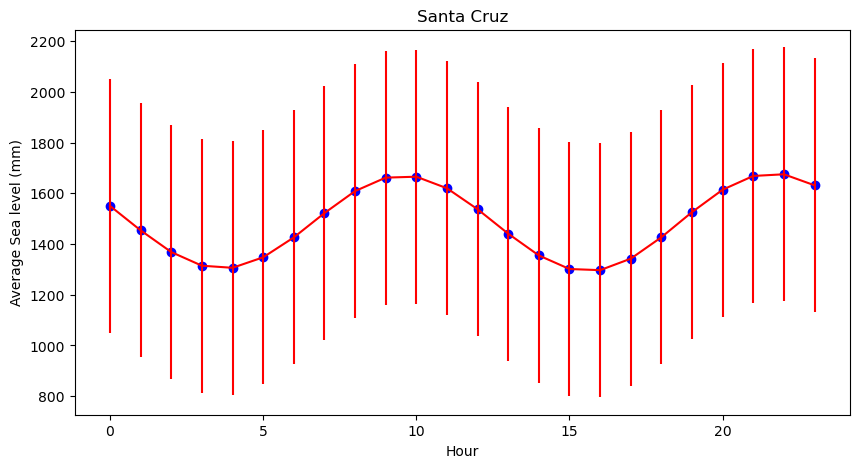

In [9]:
hour_tide = np.bincount(santa_cruz[-2], weights=santa_cruz[-1])
hours = np.bincount(santa_cruz[-2])

# Calculate the average sea level for each hour
average_santacruz = hour_tide / hours
stdv_santacruz = np.std(santa_cruz[-1])

# print(average_santacruz)

plt.figure(figsize=(10, 5))
plt.scatter(np.arange(24), average_santacruz, color='blue')
plt.errorbar(np.arange(24), average_santacruz, yerr=stdv_santacruz, fmt='', color='red')
plt.xlabel('Hour')
plt.ylabel('Average Sea level (mm)')
plt.title('Santa Cruz')
plt.show()

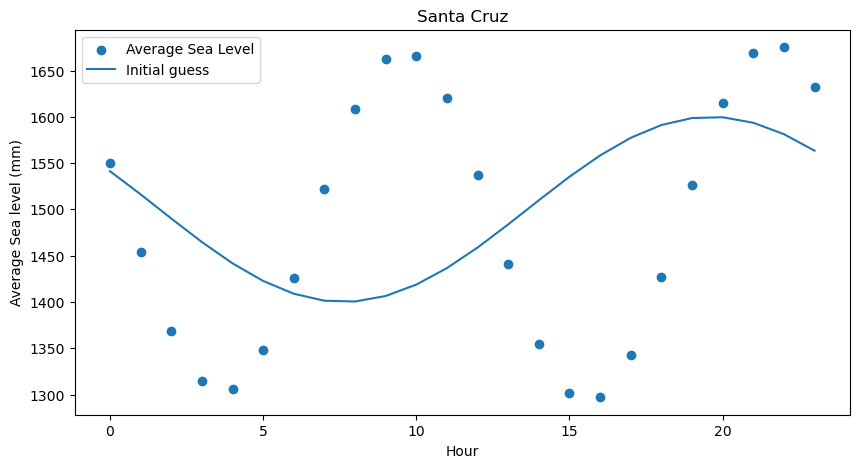

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0019603036891060865
        x: [ 1.882e+02 -5.256e-01  6.623e+00  1.486e+03]
      nit: 34
      jac: [-2.881e-09 -1.907e-07 -1.202e-08 -1.164e-10]
 hess_inv: [[ 1.030e+04 -4.554e-01  4.159e+00 -1.297e+02]
            [-4.554e-01  6.508e-03 -7.143e-02  1.198e+00]
            [ 4.159e+00 -7.143e-02  1.086e+00 -1.332e+01]
            [-1.297e+02  1.198e+00 -1.332e+01  5.408e+03]]
     nfev: 230
     njev: 46
Best Fit Values are: [ 1.88232250e+02 -5.25591542e-01  6.62332555e+00  1.48558983e+03]


In [10]:
def fit_model(a, omega, phi, r):
    """
    Generate a model for the sea level as a function of time using a sinusoidal function.

    Parameters:
    a (float): Amplitude of the sine wave
    omega (float): Angular frequency of the sine wave
    phi (float): Phase shift of the sine wave
    r (float): Vertical shift of the sine wave

    Returns:
    np.ndarray: The modeled sea level values for each hour of the day
    """
    return a * np.sin(omega * np.arange(24) + phi) + r

# Calculate the initial guess for the parameters
initial_guess = np.array([100, np.pi/12, 9, 1500])

# Plot the initial guess model against the average sea level data
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(24), average_santacruz, label='Average Sea Level')
plt.plot(np.arange(24), fit_model(*initial_guess), label='Initial guess')
plt.xlabel('Hour')
plt.ylabel('Average Sea level (mm)')
plt.title('Santa Cruz')
plt.legend()
plt.show()

def chi_sqr_stat(params):
    """
    Calculate the chi-squared statistic for the model fit.

    Parameters:
    params (list): List of parameters [a, omega, phi, r] for the model

    Returns:
    float: The chi-squared statistic
    """
    a, omega, phi, r = params
    model = fit_model(a, omega, phi, r)
    data = average_santacruz
    return np.sum((data - model)**2 / (stdv_santacruz**2))

# Perform optimization to find the best-fit parameters
tide = opt.minimize(chi_sqr_stat, initial_guess)

# Print the optimization result and best-fit parameters
print(tide)
print("Best Fit Values are:", tide.x)

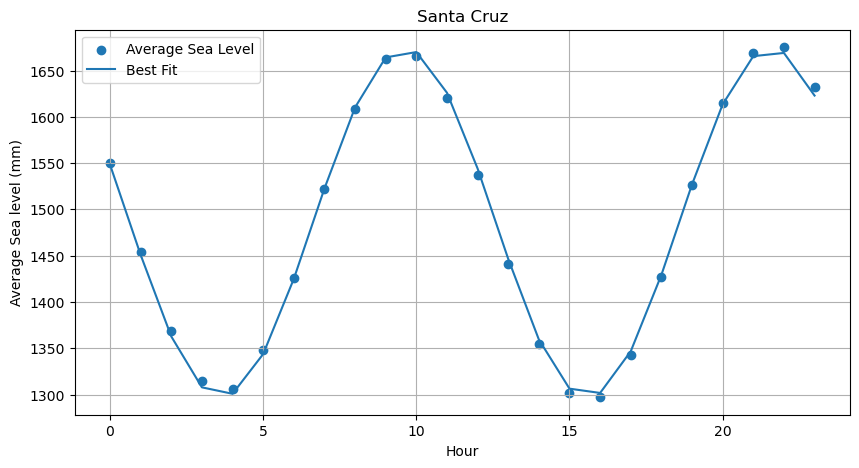

In [11]:
# Calculate the best-fit model for the sea level as a function of time using the optimized parameters
mean_t_chi = fit_model(*tide.x)

# Create a figure to plot the average sea level data and the best-fit model
plt.figure(figsize=(10, 5)) 
plt.scatter(np.arange(24), average_santacruz, label='Average Sea Level')
plt.plot(np.arange(24), mean_t_chi, label='Best Fit')
plt.xlabel('Hour')
plt.ylabel('Average Sea level (mm)')
plt.title('Santa Cruz')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Calculate global chi-squared
global_chi2 = chi_sqr_stat(tide.x)

# Reduced chi-squared
chi2_reduced = global_chi2 / (len(average_santacruz) - len(tide.x))

print(f"Global X^2: {global_chi2:.5f}")
print(f"Degrees of freedom: {len(average_santacruz) - len(tide.x)}")
print(f"Reduced X^2: {chi2_reduced:.5f}")

Global X^2: 0.00196
Degrees of freedom: 20
Reduced X^2: 0.00010


We can denote a realy small Reduced $\chi^2$ what would suggest overfitting, but according to the data, we can tell that the tendency of the function in the average tides for Santa Cruz has a perfect oscilation behaiviour, this small $\chi^2$ suggest that we fitted the model with complete accuracy

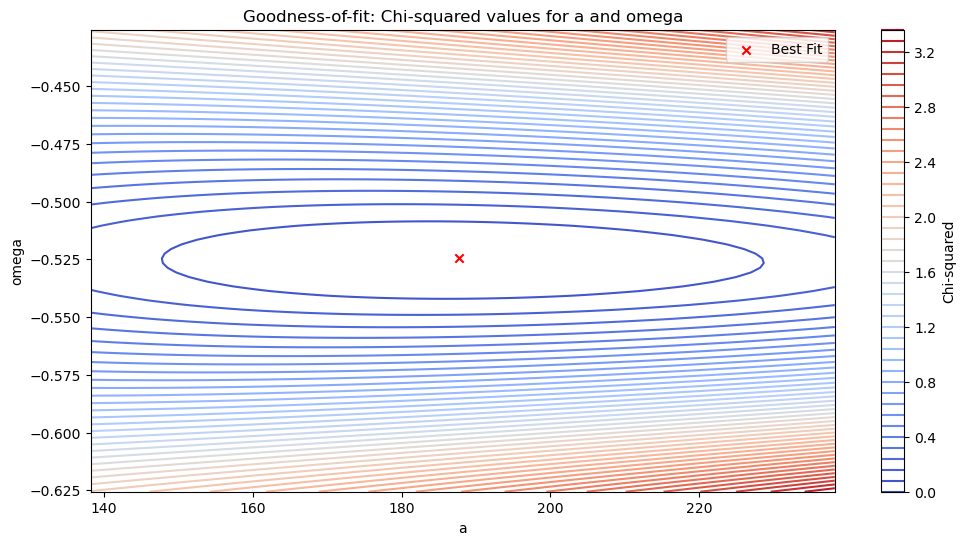

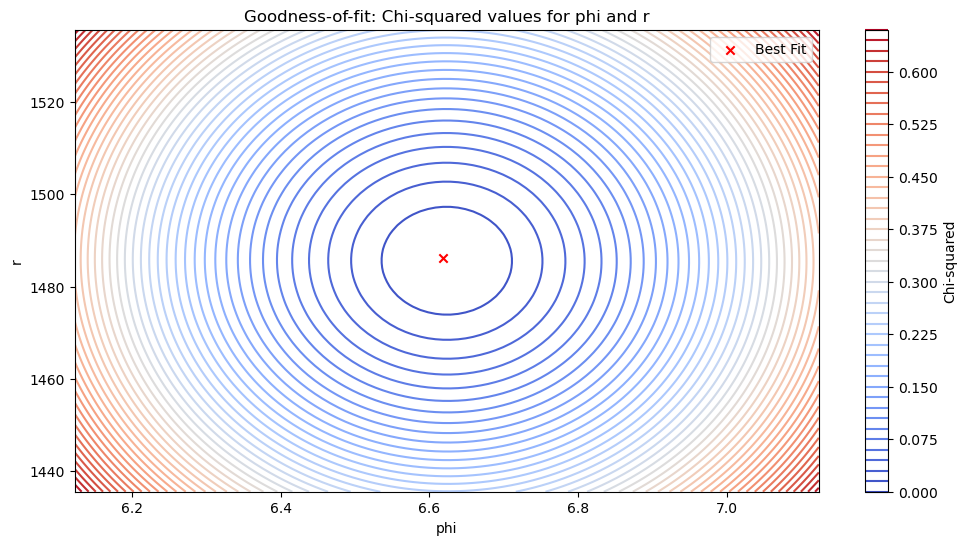

In [13]:
# Params Range
a1 = np.linspace(tide.x[0] - 50, tide.x[0] + 50, 100)
omega1 = np.linspace(tide.x[1] - 0.1, tide.x[1] + 0.1, 100)
phi1 = np.linspace(tide.x[2] - 0.5, tide.x[2] + 0.5, 100)
r1 = np.linspace(tide.x[3] - 50, tide.x[3] + 50, 100)

# Meshfgrids for params
a_mesh, omega_mesh = np.meshgrid(a1, omega1)
phi_mesh, r_mesh = np.meshgrid(phi1, r1)

# Veectorizing
chi_sqr_vec = np.vectorize(lambda a, omega: chi_sqr_stat([a, omega, tide.x[2], tide.x[3]]))
chi_squared_a_omega = chi_sqr_vec(a_mesh, omega_mesh)

chi_sqr_vec_phi_r = np.vectorize(lambda phi, r: chi_sqr_stat([tide.x[0], tide.x[1], phi, r]))
chi_squared_phi_r = chi_sqr_vec_phi_r(phi_mesh, r_mesh)

# Omega vs A plot
plt.figure(figsize=(12, 6))
plt.contour(a_mesh, omega_mesh, chi_squared_a_omega, levels=50, cmap='coolwarm')
plt.colorbar(label='Chi-squared')
min_idx = np.unravel_index(np.argmin(chi_squared_a_omega), chi_squared_a_omega.shape)
plt.scatter(a_mesh[min_idx], omega_mesh[min_idx], color='red', marker='x', label='Best Fit')
plt.xlabel('a')
plt.ylabel('omega')
plt.title('Goodness-of-fit: Chi-squared values for a and omega')
plt.legend()
plt.show()

# Phi vs R plot
plt.figure(figsize=(12, 6))
plt.contour(phi_mesh, r_mesh, chi_squared_phi_r, levels=50, cmap='coolwarm')
plt.colorbar(label='Chi-squared')
plt.scatter(phi_mesh[min_idx], r_mesh[min_idx], color='red', marker='x', label='Best Fit')
plt.xlabel('phi')
plt.ylabel('r')
plt.title('Goodness-of-fit: Chi-squared values for phi and r')
plt.legend()
plt.show()


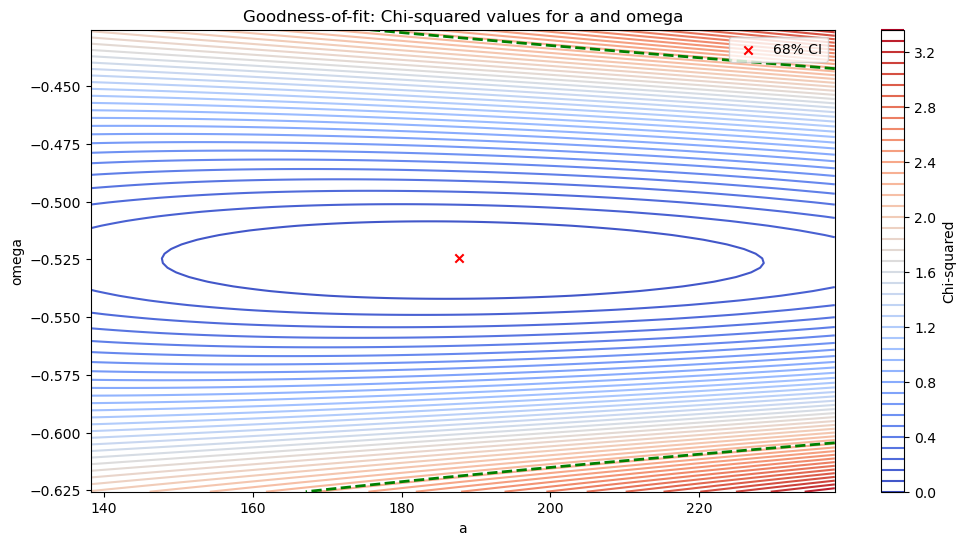

In [14]:

# Confidence interval thresholds for 2 parameters
conf_levels = [2.3, 6.18, 11.83]  

# Omega vs A plot with confidence intervals
plt.figure(figsize=(12, 6))
plt.contour(a_mesh, omega_mesh, chi_squared_a_omega, levels=50, cmap='coolwarm')
plt.colorbar(label='Chi-squared')
plt.contour(a_mesh, omega_mesh, chi_squared_a_omega, levels=conf_levels, colors=['green', 'orange', 'purple'], linestyles=['--', '--', '--'], linewidths=2)
plt.scatter(a_mesh[min_idx], omega_mesh[min_idx], color='red', marker='x', label='Best Fit')
plt.xlabel('a')
plt.ylabel('omega')
plt.title('Goodness-of-fit: Chi-squared values for a and omega')
plt.legend(['68% CI', '95% CI', '99.7% CI', 'Best Fit'])
plt.show()


### Analysis tasks:

**(i)** Based on the fitted function, what period does the tide in Santa Cruz have? What do the confidence intervals tell us?

**(j)** Can the same model be applied to the other 2 stations (Baltra and La Libertad)? If not, report appropriate best-fit functions for these stations too.

We can Define the period o of the function we had as 
$$ 
T = \frac{2 \pi}{\omega}
$$
Therefore

In [15]:
T = (2 * np.pi) / tide.x[2]
print('The period of the Tide in Santa Cruz is:' , T, '[hours]')

The period of the Tide in Santa Cruz is: 0.9486450965445391 [hours]


Now, respect to the confidence intervals, we can tell that: The elongated shape of the 68% confidence interval suggests that the parameter a has higher uncertainty compared to $\omega$. Conversely, the narrower range in $\omega$ indicates that $\omega$ is better constrained so on small deviations from the best-fit value result in a faster increase in the chi-squared value.The parameters are not independent; a change in one often requires an adjustment in the other for the model to maintain a good fit. The best-fit point (red "X") lies near the center of the confidence region, which is expected for a well-behaved model.

Now, lets check if the model is able to be applied to Baltra and La libertad

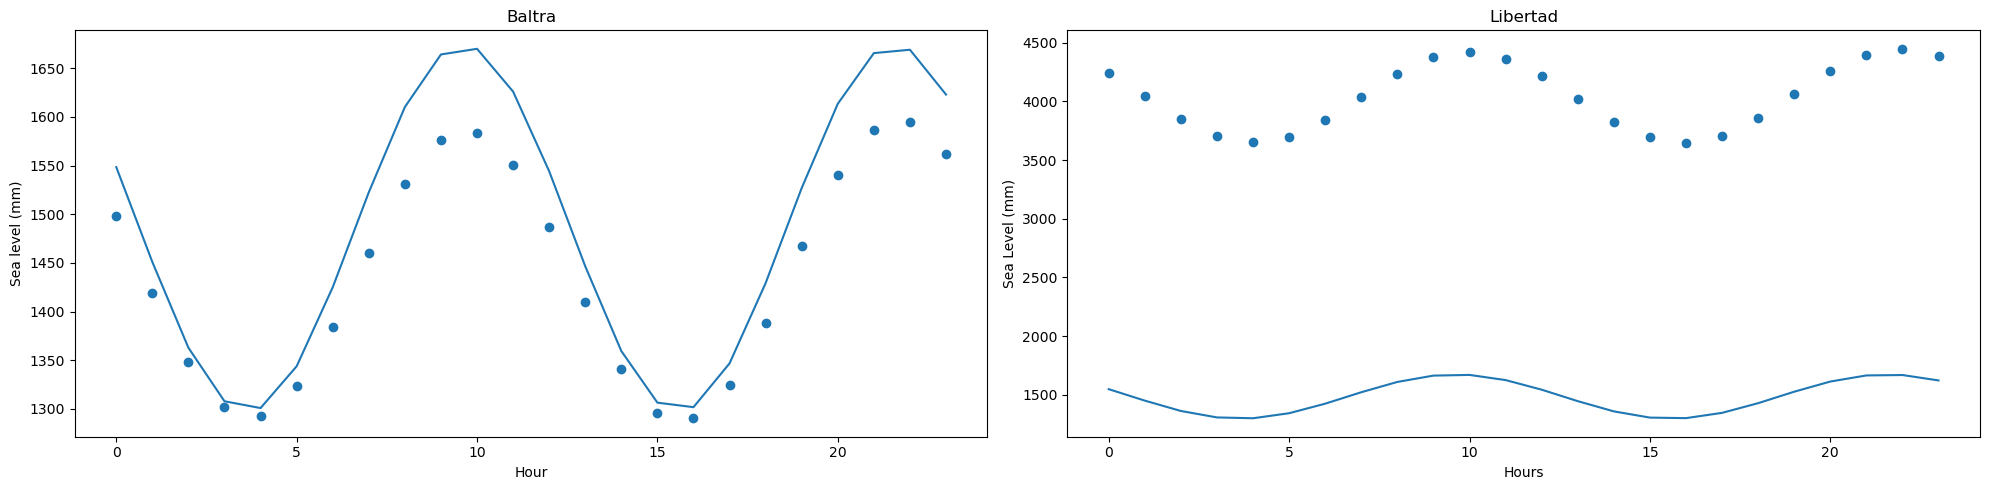

In [16]:
# Calculate the total sea level for each hour for Baltra and La Libertad
hour_tide_baltra = np.bincount(baltra[-2], weights=baltra[-1])
hour_tide_libertad = np.bincount(libertad[-2], weights=libertad[-1])

# Calculate the average sea level for each hour for Baltra and La Libertad
average_baltra = hour_tide_baltra / hours
stdv_baltra = np.std(baltra[-1])
average_libertad = hour_tide_libertad / hours
stdv_libertad = np.std(libertad[-1])

# Create a figure with 2 subplots for Baltra and La Libertad
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Plot the average sea level against the hours for Baltra and La Libertad
ax[0].scatter(np.arange(24), average_baltra, label='Baltra')
ax[1].scatter(np.arange(24), average_libertad, label='Libertad')

# Plot the initial guess model against the average sea level data for Baltra and La Libertad
ax[0].plot(np.arange(24), fit_model(*tide.x), label='Initial guess')
ax[1].plot(np.arange(24), fit_model(*tide.x), label='Initial guess')

# Set labels and titles for each subplot
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Sea level (mm)')
ax[0].set_title('Baltra')
ax[1].set_xlabel('Hours')
ax[1].set_ylabel('Sea Level (mm)')
ax[1].set_title('Libertad')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



As, we can see, it is not possible to apply the same model to this data. So lets fit the model again with the data per each Island, so lets fit the model again for each dataset

In [17]:
def chi_sqr_stat_balrta(params):
    """
    Calculate the chi-squared statistic for the model fit for Baltra.

    Parameters:
    params (list): List of parameters [a, omega, phi, r] for the model

    Returns:
    float: The chi-squared statistic
    """
    a, omega, phi, r = params
    model = fit_model(a, omega, phi, r)
    data = average_baltra
    return np.sum((data - model)**2 / (stdv_baltra**2))

# Initial guess for the parameters for La Libertad
initial_guess_libertad = np.array([100, np.pi/12, 9, 4000])

def chi_sqr_stat_libertad(params):
    """
    Calculate the chi-squared statistic for the model fit for La Libertad.

    Parameters:
    params (list): List of parameters [a, omega, phi, r] for the model

    Returns:
    float: The chi-squared statistic
    """
    a, omega, phi, r = params
    model = fit_model(a, omega, phi, r)
    data = average_libertad
    return np.sum((data - model)**2 / (stdv_libertad**2))

# Perform optimization to find the best-fit parameters for Baltra
tide_baltra = opt.minimize(chi_sqr_stat_balrta, initial_guess)

# Perform optimization to find the best-fit parameters for La Libertad
tide_libertad = opt.minimize(chi_sqr_stat_libertad, initial_guess_libertad)

# Print the optimization result and best-fit parameters for Baltra
print(tide_baltra)
print("Best Fit Values for Baltra are:", tide_baltra.x)

# Print the optimization result and best-fit parameters for La Libertad
print(tide_libertad)
print("Best Fit Values for La Libertad are:", tide_libertad.x)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0010968327378831748
        x: [ 1.508e+02 -5.264e-01  6.672e+00  1.439e+03]
      nit: 41
      jac: [-8.877e-10  2.421e-06 -1.040e-07 -6.257e-10]
 hess_inv: [[ 1.277e+04 -4.852e-01  6.293e+00 -1.278e+02]
            [-4.852e-01  1.441e-02 -1.737e-01  2.045e+00]
            [ 6.293e+00 -1.737e-01  2.768e+00 -2.281e+01]
            [-1.278e+02  2.045e+00 -2.281e+01  6.816e+03]]
     nfev: 235
     njev: 47
Best Fit Values for Baltra are: [ 1.50772687e+02 -5.26365494e-01  6.67188275e+00  1.43944995e+03]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.004409225899148111
        x: [ 3.927e+02 -5.274e-01  6.823e+00  4.039e+03]
      nit: 37
      jac: [ 1.543e-08 -8.602e-06 -4.240e-07  1.409e-08]
 hess_inv: [[ 1.538e+04 -2.835e-02  4.218e-01 -3.156e+02]
            [-2.835e-02  2.349e-03 -2.453e-02  1.164e+00]
            [ 4.218e-01 -2.453e-02  3.615e-01 -

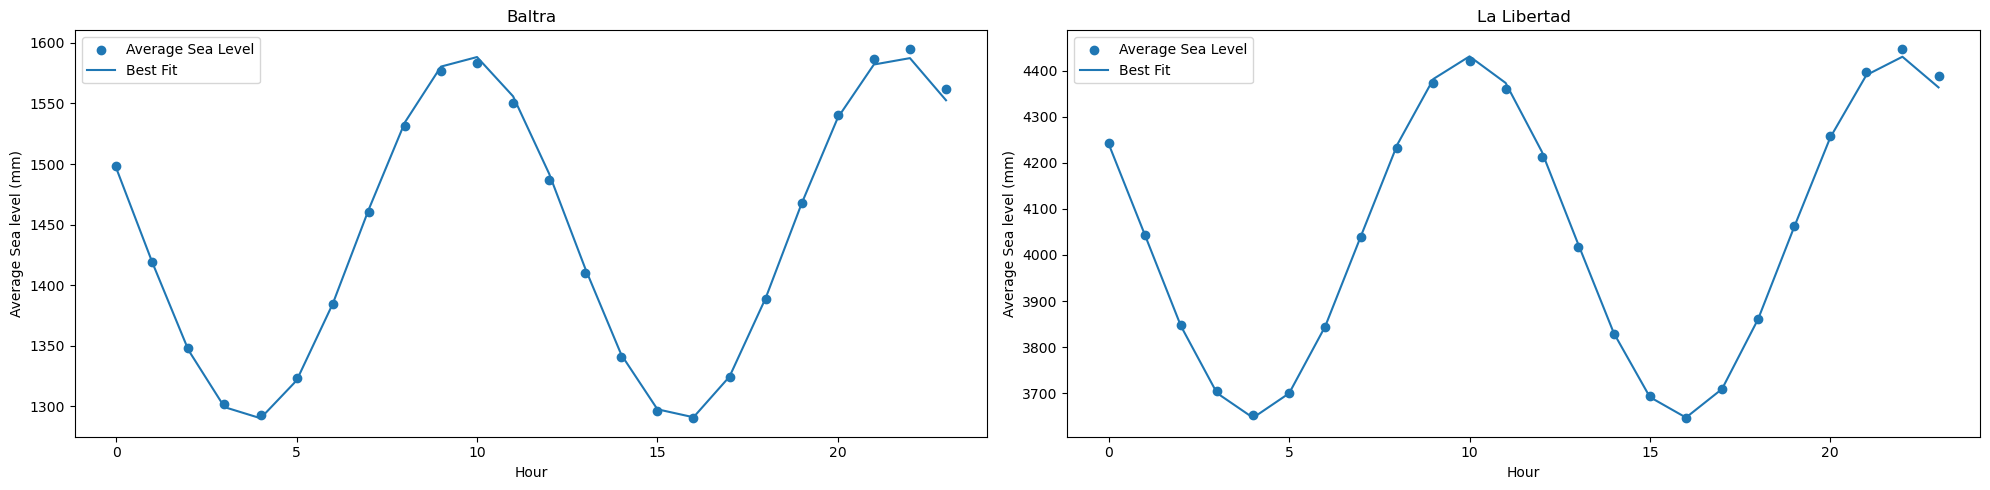

In [18]:
# Fit the model to the data for Baltra and La Libertad using the optimized parameters
fit_baltra = fit_model(*tide_baltra.x)
fit_libertad = fit_model(*tide_libertad.x)

# Create a figure with 2 subplots to plot the average sea level data and the best-fit model for Baltra and La Libertad
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Plot the average sea level data and the best-fit model for Baltra
ax[0].scatter(np.arange(24), average_baltra, label='Average Sea Level')
ax[0].plot(np.arange(24), fit_baltra, label='Best Fit')
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Average Sea level (mm)')
ax[0].set_title('Baltra')
ax[0].legend()

# Plot the average sea level data and the best-fit model for La Libertad
ax[1].scatter(np.arange(24), average_libertad, label='Average Sea Level')
ax[1].plot(np.arange(24), fit_libertad, label='Best Fit')
ax[1].set_xlabel('Hour')
ax[1].set_ylabel('Average Sea level (mm)')
ax[1].set_title('La Libertad')
ax[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In every plot of the fitted functions we can denote some error on the last points, due to the dimension of the plot arrays, if we increment the definition, the function would pass through every point smoothly
